# Set distribution 2D

In [5]:
import math
import cmath
import cupy as np
import matplotlib.pyplot as plt
import cmasher as cmr

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from crsq.models.hydrogen2d import PsiH2D
from crsq.blocks.embed2D import StateEmbedGate2D
import crsq.utils.statevector as stv

def draw_graph(cu_qxv, cu_qyv, cu_data, dq, name, zmin, zmax):
    """ set 2D state data into qubits and draw a 3d graph.
        cu_qxv: value[i,j] is x coord of entry[i,j]
        cu_qyv: value[i,j] is y coord of entry[i,j]
        cu_data: value[i,j] is entry[i,j]
    """

    qyv = np.asnumpy(cu_qyv)
    qxv = np.asnumpy(cu_qxv)

    frame = StateEmbedGate2D(cu_data)
    qc = frame.circuit
    qc.save_statevector()
    backend = AerSimulator()
    tqc = transpile(qc, backend)

    result = backend.run(tqc).result()
    sv = result.get_statevector()

    colormap_name = 'cmr.guppy'
    fig, axs = plt.subplots(1,3, figsize=(15, 5), subplot_kw={'projection': '3d'}, layout='constrained')
    colormap = plt.get_cmap(colormap_name)

    data2d = stv.extract_dist2d(tqc, sv, "row", "col")

    cu_data2d = np.array(data2d)

    ax = axs[0]
    ax.set_title('|ψ|')
    ax.set_zlim3d(zmin, zmax)
    ax.set_xlabel('row')
    ax.set_ylabel('col')
    ax.plot_surface(qyv, qxv, np.asnumpy(np.absolute(cu_data2d) / dq), cmap=colormap, vmin=zmin, vmax=zmax)

    ax = axs[1]
    ax.set_title('Re(ψ)')
    ax.set_zlim3d(zmin, zmax)
    ax.set_xlabel('y')
    ax.set_ylabel('x')
    ax.plot_surface(qyv, qxv, np.asnumpy((1/dq)*np.real(cu_data2d)), cmap=colormap, vmin=zmin, vmax=zmax)

    ax = axs[2]
    ax.set_title('Im(ψ)')
    ax.set_zlim3d(zmin, zmax)
    ax.set_xlabel('y')
    ax.set_ylabel('x')
    ax.plot_surface(qyv, qxv, np.asnumpy((1/dq)*np.imag(cu_data2d)), cmap=colormap, vmin=zmin, vmax=zmax)

    # fig.savefig("output/diagrams/rfqrom-n5.png")
    fig.savefig(f"output/diagrams/emb2d-n5-{name}.png")
    plt.show()


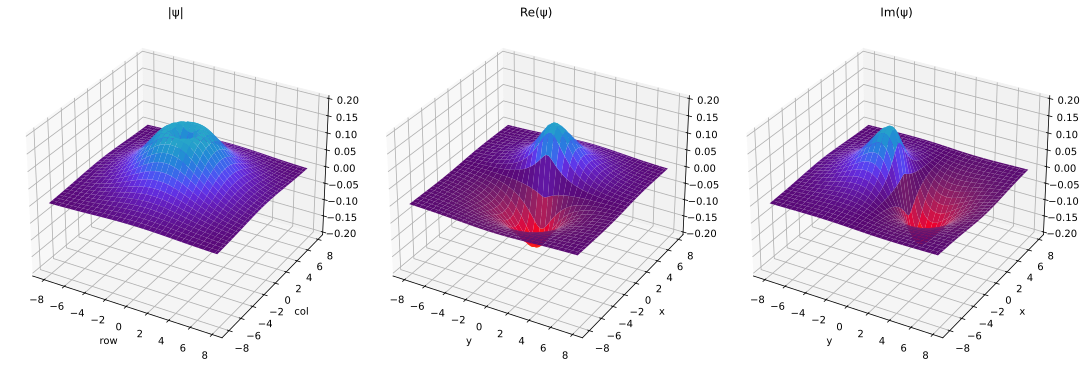

In [6]:
dim = 2  # 1 dimension
n1 = 6 # bits per coordinate
M=1<<n1
L = 16 # 16 bohr

M = 2**n1
dq = L/M

# prepare grid of coordinate values
xv = np.zeros((M, M))
yv = np.zeros((M, M))
for i in range(M):
    yv[:,i] = np.linspace(-M//2, M//2-1, M)
    xv[i,:] = np.linspace(-M//2, M//2-1, M)
# discretized wave number values
# value of V
qxv = xv * dq
qyv = yv * dq

# prepare data
## quantum numbers
qn_n = 1
qn_m = -1
# 2D Hydrogen model wave function generator:
psifunc2 = PsiH2D(0, 0, dq/2, qn_n, qn_m)
psi0 = dq*psifunc2(qxv, qyv)

draw_graph(qxv, qyv, psi0, dq, f"H(n={qn_n},m={qn_m})", zmin=-0.2, zmax=0.2)

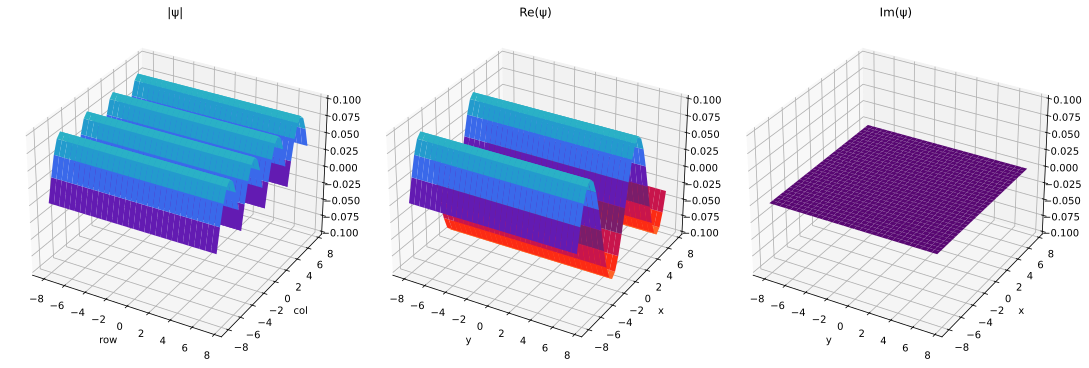

In [7]:
dim = 2  # 1 dimension
n1 = 5 # bits per coordinate
M=1<<n1
L = 16 # 16 bohr

M = 2**n1
dq = L/M

# prepare grid of coordinate values
xv = np.zeros((M, M))
yv = np.zeros((M, M))
for i in range(M):
    yv[:,i] = np.linspace(-M//2, M//2-1, M)
    xv[i,:] = np.linspace(-M//2, M//2-1, M)
# discretized wave number values
# value of V
qxv = xv * dq
qyv = yv * dq

# prepare data
data = np.zeros((M,M), dtype=complex)
for row in range(M):
    for col in range(M):
        x = xv[row, col]
        y = yv[row, col]
        data[row, col] = cmath.sin(math.pi*x/8)

draw_graph(qxv, qyv, data, dq, f"sin_x", -0.1, 0.1)

[ 2.44929360e-16+0.j  3.82683432e-01+0.j  7.07106781e-01+0.j
  9.23879533e-01+0.j  1.00000000e+00-0.j  9.23879533e-01-0.j
  7.07106781e-01-0.j  3.82683432e-01-0.j -1.22464680e-16-0.j
 -3.82683432e-01-0.j -7.07106781e-01-0.j -9.23879533e-01-0.j
 -1.00000000e+00+0.j -9.23879533e-01+0.j -7.07106781e-01+0.j
 -3.82683432e-01+0.j  0.00000000e+00+0.j  3.82683432e-01+0.j
  7.07106781e-01+0.j  9.23879533e-01+0.j  1.00000000e+00+0.j
  9.23879533e-01-0.j  7.07106781e-01-0.j  3.82683432e-01-0.j
  1.22464680e-16-0.j -3.82683432e-01-0.j -7.07106781e-01-0.j
 -9.23879533e-01-0.j -1.00000000e+00-0.j -9.23879533e-01+0.j
 -7.07106781e-01+0.j -3.82683432e-01+0.j]


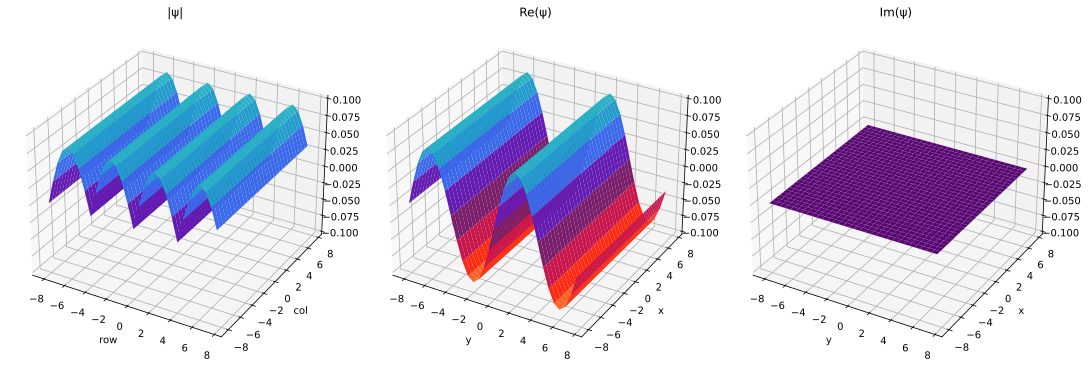

In [8]:
dim = 2  # 1 dimension
n1 = 5 # bits per coordinate
M=1<<n1
L = 16 # 16 bohr

M = 2**n1
dq = L/M

# prepare grid of coordinate values
xv = np.zeros((M, M))
yv = np.zeros((M, M))
for i in range(M):
    yv[:,i] = np.linspace(-M//2, M//2-1, M)
    xv[i,:] = np.linspace(-M//2, M//2-1, M)
# discretized wave number values
# value of V
qxv = xv * dq
qyv = yv * dq

# prepare data
data = np.zeros((M,M), dtype=complex)
for row in range(M):
    for col in range(M):
        x = xv[row, col]
        y = yv[row, col]
        data[row, col] = cmath.sin(math.pi*y/8)

print(data[:,0])

draw_graph(qxv, qyv, data, dq, f"sin_y", -0.1, 0.1)